<a href="https://colab.research.google.com/github/harshit-538/ML-DL/blob/main/92_tf_input_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tensorflow input pipelines:**
- When too much data is there and limited RAM so while training load data into specific structure in RAM from hard disk and then train model.
- And that specific data structure is tf.data.datasets
- load -> map(convert images to numbers/np array) -> filtering blur images -> scaling

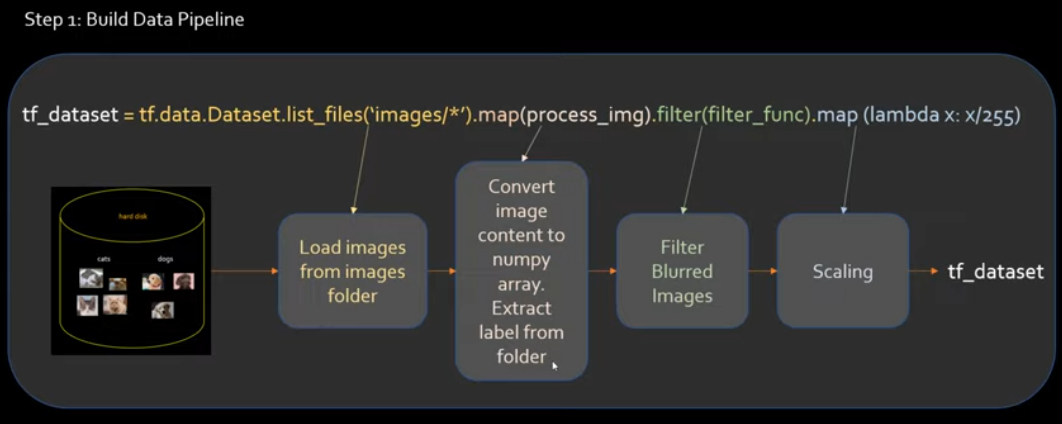

## Benefits of tf input pipelines:
 - easy data handle
 - can apply various transformation.

In [1]:
import tensorflow as tf

In [2]:
daily_sales_numbers = [21,22,-108,31,-1,32,34,31]

In [4]:
tf_dataset = tf.data.Dataset.from_tensor_slices(daily_sales_numbers)

In [9]:
for sales in tf_dataset.as_numpy_iterator():
  print(sales)

for sales in tf_dataset.take(3):
  print(sales)

21
22
-108
31
-1
32
34
31
tf.Tensor(21, shape=(), dtype=int32)
tf.Tensor(22, shape=(), dtype=int32)
tf.Tensor(-108, shape=(), dtype=int32)


In [10]:
tf_dataset = tf_dataset.filter(lambda x: x > 0)

for sales in tf_dataset.as_numpy_iterator():
  print(sales)

21
22
31
32
34
31


In [11]:
tf_dataset = tf_dataset.map(lambda x: x*72)

for sales in tf_dataset.as_numpy_iterator():
  print(sales)

1512
1584
2232
2304
2448
2232


In [12]:
tf_dataset = tf_dataset.shuffle(3)

for sales in tf_dataset.as_numpy_iterator():
  print(sales)

1584
2304
1512
2232
2232
2448


In [14]:
for saled_batch in tf_dataset.batch(3):
  print(saled_batch)

tf.Tensor([2232 1584 2448], shape=(3,), dtype=int32)
tf.Tensor([2304 2232 1512], shape=(3,), dtype=int32)


In [18]:
tf_dataset = tf.data.Dataset.from_tensor_slices(daily_sales_numbers)

tf_dataset = tf_dataset.filter(lambda x: x>0).map(lambda y: y*85).shuffle(3).batch(2)

for data in tf_dataset:
  print(data)

tf.Tensor([2635 1785], shape=(2,), dtype=int32)
tf.Tensor([2890 2720], shape=(2,), dtype=int32)
tf.Tensor([1870 2635], shape=(2,), dtype=int32)


## **Optimizing pipelines using prefetch and cache:**
  - cpu will load data from ram and training will be run on gpu.
  - so cpu can pre load batches while gpu is running model.

    tf.data.Datsets.prefetch(1)

  - prefetch 1 batch

    tf.data.Datasets.cache()

  - it will load images only in first epoch and then onwards used cached images.